# Tuned XGBoost Model — Load & Evaluate

Loads the trained model saved at `data/pipeline_output_tuned/xgb_tuned_model.joblib`,
inspects it, reproduces test-set predictions, and visualises results.

## 1. Import Required Libraries

In [1]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.metrics import mean_squared_error

print("Libraries loaded.")

Libraries loaded.


## 2. Define Model & Output Paths

In [2]:
# All paths relative to the repo root
BASE_DIR    = Path("..").resolve()
OUTPUT_DIR  = BASE_DIR / "data" / "pipeline_output_tuned"

MODEL_PATH      = OUTPUT_DIR / "xgb_tuned_model.joblib"
SUMMARY_PATH    = OUTPUT_DIR / "xgb_final_summary.json"
PREDICTIONS_CSV = OUTPUT_DIR / "xgb_test_predictions.csv"
FEATURES_CSV    = OUTPUT_DIR / "mifs_selected_features.csv"
KSWEEP_CSV      = OUTPUT_DIR / "mifs_k_sweep.csv"

for p in [MODEL_PATH, SUMMARY_PATH, PREDICTIONS_CSV]:
    status = "✓" if p.exists() else "✗ MISSING"
    print(f"  {status}  {p.name}")

  ✓  xgb_tuned_model.joblib
  ✓  xgb_final_summary.json
  ✓  xgb_test_predictions.csv


## 3. Load the Model

In [3]:
model = joblib.load(MODEL_PATH)
print(f"Model loaded: {type(model).__name__}")

Model loaded: XGBRegressor


## 4. Verify the Model — Summary & Hyperparameters

In [4]:
with open(SUMMARY_PATH) as f:
    summary = json.load(f)

print("=" * 55)
print("TUNED MODEL SUMMARY")
print("=" * 55)
print(f"  Model type   : {summary['model']}")
print(f"  Features (K) : {summary['best_k']}")
print(f"  Train samples: {summary['train_samples']}")
print(f"  Val samples  : {summary['val_samples']}")
print(f"  Test samples : {summary['test_samples']}")
print()
print("  Best hyperparameters:")
for k, v in summary["best_params"].items():
    print(f"    {k:<22s}: {v}")
print()
print("  Test metrics:")
print(f"    RMSE : {summary['test_rmse']:.4f}")
print(f"    ACC  : {summary['test_acc']:.4f}")
print("=" * 55)

TUNED MODEL SUMMARY
  Model type   : XGBRegressor (tuned)
  Features (K) : 18
  Train samples: 457
  Val samples  : 48
  Test samples : 35

  Best hyperparameters:
    n_estimators          : 500
    max_depth             : 6
    learning_rate         : 0.1
    subsample             : 0.7
    colsample_bytree      : 0.85
    min_child_weight      : 5
    reg_alpha             : 0

  Test metrics:
    RMSE : 0.8906
    ACC  : 0.8078


## 5. Test Predictions — Actual vs Predicted

RMSE (from CSV): 0.8906  |  ACC (from CSV): 0.8078


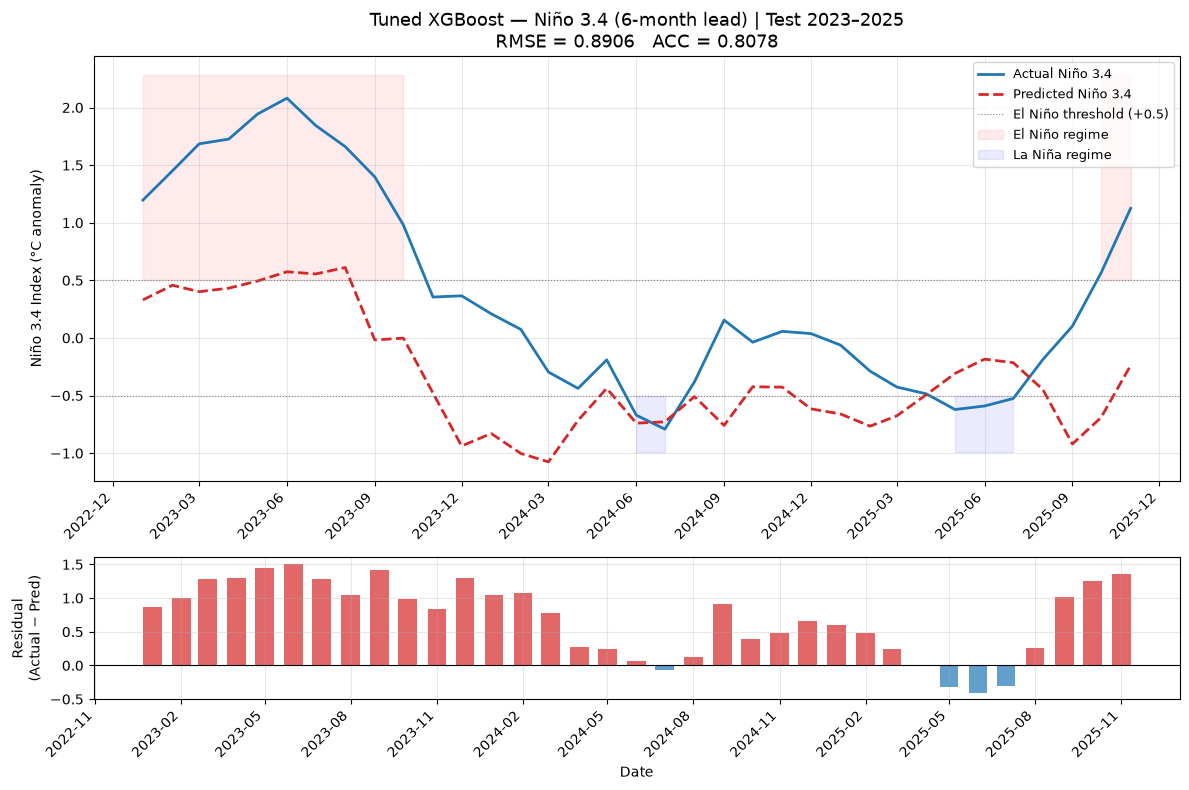

Plot saved to pipeline_output_tuned/test_predictions_plot.png


In [5]:
preds = pd.read_csv(PREDICTIONS_CSV, parse_dates=["window_end"])

actual    = preds["actual_nino34"].values
predicted = preds["predicted_nino34"].values
dates     = preds["window_end"]

# Metrics from saved predictions (sanity-check against summary)
rmse = np.sqrt(mean_squared_error(actual, predicted))
acc  = np.corrcoef(actual, predicted)[0, 1]
print(f"RMSE (from CSV): {rmse:.4f}  |  ACC (from CSV): {acc:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 1]})

# Top: time series
ax = axes[0]
ax.plot(dates, actual,    label="Actual Niño 3.4",    color="#1f77b4", linewidth=2)
ax.plot(dates, predicted, label="Predicted Niño 3.4", color="#d62728",
        linewidth=2, linestyle="--")
ax.axhline(0.5,  color="gray", linewidth=0.8, linestyle=":", label="El Niño threshold (+0.5)")
ax.axhline(-0.5, color="gray", linewidth=0.8, linestyle=":")
ax.fill_between(dates, 0.5, actual.max() + 0.2,
                where=(actual >= 0.5), alpha=0.08, color="red", label="El Niño regime")
ax.fill_between(dates, actual.min() - 0.2, -0.5,
                where=(actual <= -0.5), alpha=0.08, color="blue", label="La Niña regime")
ax.set_title(f"Tuned XGBoost — Niño 3.4 (6-month lead) | Test 2023–2025\n"
             f"RMSE = {rmse:.4f}   ACC = {acc:.4f}", fontsize=13)
ax.set_ylabel("Niño 3.4 Index (°C anomaly)")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax.grid(True, alpha=0.3)

# Bottom: residuals
residuals = actual - predicted
ax2 = axes[1]
ax2.bar(dates, residuals, color=["#d62728" if r > 0 else "#1f77b4" for r in residuals],
        width=20, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Residual\n(Actual − Pred)")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_predictions_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to pipeline_output_tuned/test_predictions_plot.png")

## 6. Feature Importances

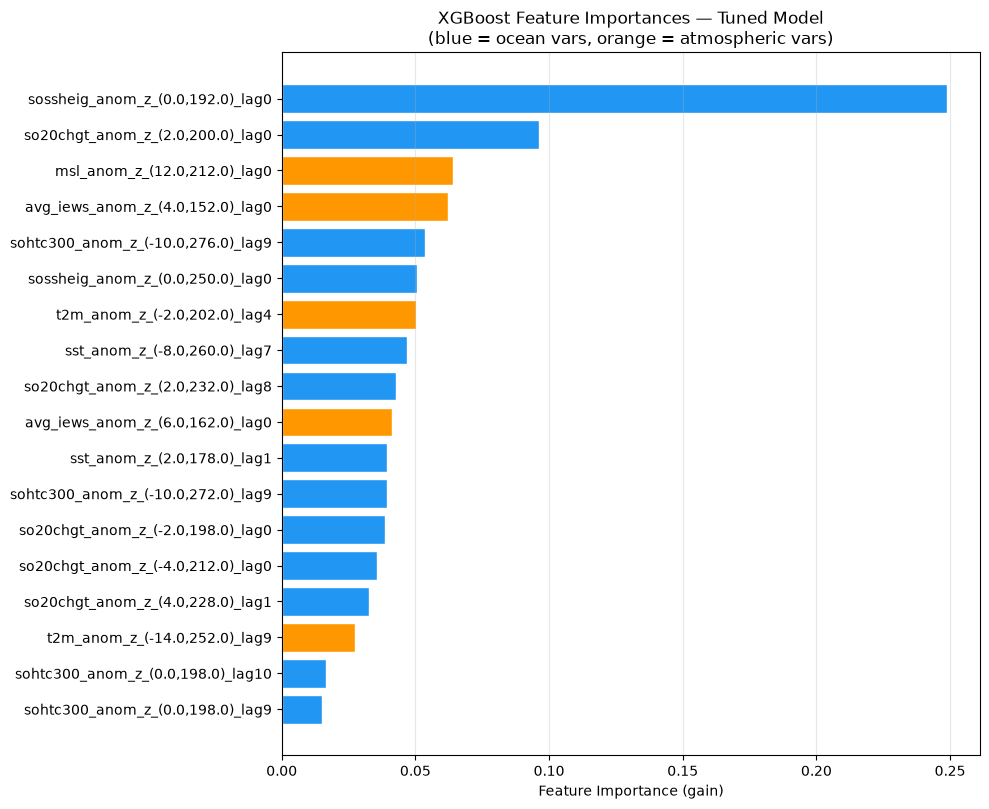


Top 5 most important features:
  0.2487  sossheig_anom_z_(0.0,192.0)_lag0
  0.0961  so20chgt_anom_z_(2.0,200.0)_lag0
  0.0639  msl_anom_z_(12.0,212.0)_lag0
  0.0620  avg_iews_anom_z_(4.0,152.0)_lag0
  0.0535  sohtc300_anom_z_(-10.0,276.0)_lag9


In [6]:
feature_names = summary["selected_features"]

# XGBRegressor exposes feature_importances_ (gain-based)
importances = model.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 0.4 * len(fi) + 1))
colors = ["#2196F3" if "sst" in f or "sohtc" in f or "so20" in f or "soss" in f
          else "#FF9800" for f in fi.index]
ax.barh(fi.index, fi.values, color=colors, edgecolor="white")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost Feature Importances — Tuned Model\n"
             "(blue = ocean vars, orange = atmospheric vars)")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importances_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
for name, val in fi.sort_values(ascending=False).head(5).items():
    print(f"  {val:.4f}  {name}")

## 7. MIFS K-Sweep — How Feature Count Affects Validation RMSE

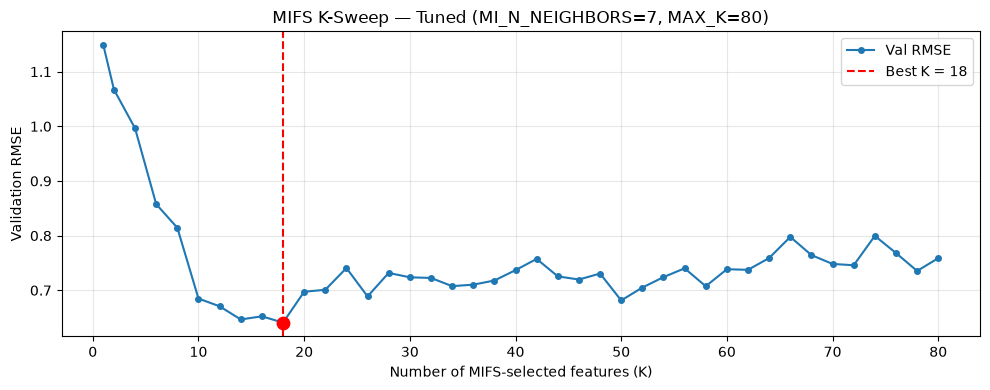

In [7]:
ksweep = pd.read_csv(KSWEEP_CSV)
best_k = summary["best_k"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ksweep["K"], ksweep["val_rmse"], marker="o", markersize=4,
        color="#1f77b4", linewidth=1.5, label="Val RMSE")
ax.axvline(best_k, color="red", linestyle="--", linewidth=1.5,
           label=f"Best K = {best_k}")
ax.scatter([best_k], [ksweep.loc[ksweep["K"] == best_k, "val_rmse"].iloc[0]],
           color="red", zorder=5, s=80)
ax.set_xlabel("Number of MIFS-selected features (K)")
ax.set_ylabel("Validation RMSE")
ax.set_title("MIFS K-Sweep — Tuned (MI_N_NEIGHBORS=7, MAX_K=80)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mifs_ksweep_plot.png", dpi=150, bbox_inches="tight")
plt.show()